# Protecting Capital: Which Sectors Weather Market Crashes Best?
## Overview
This project analyzes how different stock market sectors behave during periods of significant market stress. Using historical adjusted closing price data sourced from Yahoo Finance via the tidyquant package in R, we examine 47 stocks across 6 sectors — Technology, Healthcare, Energy, Financial, Consumer Staples, and Defense — alongside the S&P 500 index (SPY) as a market benchmark.

## Research Question
During stock market downturns, which sectors experience the smallest percent decline, and how does sector performance hierarchy shift across different types of market crashes?

## Hypothesis
This analysis tests the theory that while defensive sectors (Healthcare and Consumer Staples) reliably offer superior downside protection across all market downturns, the performance hierarchy among cyclical sectors is highly dependent on the macroeconomic catalyst. Specifically, it is hypothesized that Energy will rank as the worst-performing cyclical sector during demand-driven crashes such as the 2020 Covid-19 crash, but will act as a primary outperformer during supply or inflation driven shocks such as the 2022 Bear Market.

## Methodology
Two historically significant and structurally distinct market crashes are examined: the Covid-19 crash of February-March 2020, which was driven by an external demand shock, and the 2022 Bear Market of January-October 2022, which was driven by aggressive monetary tightening to combat inflation. Three metrics are used to evaluate sector behavior across both crashes: Maximum Drawdown measuring capital loss, Crash Beta measuring sensitivity relative to the market, and Recovery Time measuring how long it took for each sector to fully restore its pre-crash value. Comparing these metrics across two crashes with different catalysts allows us to test whether sector defensive properties are consistent or crash-type dependent.

## Dataset:
Data spans from January 1962 to present day, though meaningful cross-sector comparison begins in the late 1990s when all stocks in the dataset had begun trading. Adjusted closing prices are used throughout to account for stock splits and dividend payments. The S&P 500 ETF (SPY) is used as the market benchmark.

### Phase 1: Imports, Downloading Data, Saving/Loading CSV, Normalize Prices ###

#### Section 0: Install and Load Packages ####

Run only the first time. After packages are installed you can comment out the install lines (put # before them)

In [113]:
#packages <- c("tidyquant", "tidyverse", "scales", "lubridate")
 
#installed_pkgs <- rownames(installed.packages())
#to_install     <- packages[!packages %in% installed_pkgs]
#if (length(to_install) > 0) {
#  install.packages(to_install, dependencies = TRUE)
#}
 
library(tidyquant)   
library(tidyverse)   
library(scales)      
library(lubridate)   
 
cat("Packages loaded successfully.\n")

Packages loaded successfully.


#### Section 1: Define Stocks Based on Sector Groups ####

In [114]:
# Dictionary to keep track of all stocks in their individual sectors + var for S&P500.
dic <- list(
  Technology = c("NVDA", "AAPL", "GOOGL", "MSFT", "AVGO", "AMZN", "CRM", "NOW"),
  Healthcare = c("UNH",  "LLY",  "JNJ", "TMO", "ISRG", "MDT", "VRTX", "AMGN"),
  Energy = c("XOM", "CVX", "VLO", "ENB",  "WMB",  "NEE",  "SLB"),   
  Financial = c("JPM",  "BAC", "V", "MA", "GS",  "BLK",  "SPGI","CME"),
  Consumer_Staples = c("WMT", "PG",   "KO", "PEP", "COST", "PM", "MDLZ", "CL"),
  Defense = c("LMT", "RTX", "GD", "NOC", "GE", "LHX", "TDG", "BA")
)
# S&P 500 proxy
idx <- "SPY" 

#Flatten list for all stocks.
all_stocks <- c(unlist(dic, use.names = FALSE), idx)

# Correctly classify stocks to their respective sectors
sector_map <- tribble(
    ~stock, ~sector,
    "NVDA",  "Technology",   "AAPL",  "Technology",  "GOOGL", "Technology",
    "MSFT",  "Technology",   "AVGO",  "Technology",  "AMZN",  "Technology",
    "CRM",   "Technology",   "NOW",   "Technology",
    "UNH",   "Healthcare",   "LLY",   "Healthcare",  "JNJ",   "Healthcare",
    "TMO",   "Healthcare",   "ISRG",  "Healthcare",  "MDT",   "Healthcare",
    "VRTX",  "Healthcare",   "AMGN",  "Healthcare",
    "XOM",   "Energy",       "CVX",   "Energy",      "VLO",   "Energy",
    "ENB",   "Energy",       "WMB",   "Energy",      "NEE",   "Energy",
    "SLB",   "Energy",
    "JPM",   "Financial",    "BAC",   "Financial",   "V",     "Financial",
    "MA",    "Financial",    "GS",    "Financial",   "BLK",   "Financial",
    "SPGI",  "Financial",    "CME",   "Financial",
    "WMT",   "Consumer_Staples",  "PG",   "Consumer_Staples",
    "KO",    "Consumer_Staples",  "PEP",  "Consumer_Staples",
    "COST",  "Consumer_Staples",  "PM",   "Consumer_Staples",
    "MDLZ",  "Consumer_Staples",  "CL",   "Consumer_Staples",
    "LMT",   "Defense",      "RTX",   "Defense",     "GD",    "Defense",
    "NOC",   "Defense",      "GE",    "Defense",     "LHX",   "Defense",
    "TDG",   "Defense",      "BA",    "Defense",
    "SPY",   "Market_Index"
)

start_date <- "1962-01-01"

cat(sprintf("All_Stocks: %d stocks + SPY across %d sectors\n",
            length(all_stocks) - 1, length(dic)))

All_Stocks: 47 stocks + SPY across 6 sectors


#### Section 2: Download Data ####

In [ ]:
# Run this once, then comment it out after the CSV is saved
raw <- tq_get(all_stocks,
    get  = "stock.prices",   # pulls adjusted close + OHLCV from Yahoo Finance
    from = start_date,
    to   = Sys.Date() - 1)
 
# Pivot to wide format: rows = dates, columns = stocks 
df <- raw %>%
  select(symbol, date, adjusted) %>%  # keep only adjusted close price
  pivot_wider(names_from  = symbol,
              values_from = adjusted) %>%
  arrange(date)                              
 
# Save to CSV so you never have to re-download
write_csv(df, "ready_stocks.csv")
cat("Successfully saved dataframe as ready_stocks.csv\n")

Once successfully, you can just access the csv by loading with r code instead of having to redownload the dataset everytime the notebook is launched, meaning after the initial run, you can skip section 2 entirely to access the data!

#### Section 3: Load from CSV ####

In [115]:
df <- read_csv("ready_stocks.csv",
               show_col_types = FALSE) %>%
  mutate(date = as.Date(date)) %>%
  arrange(date)
 
cat("Loaded ready_stocks.csv successfully.\n")
cat(sprintf("Shape: %d rows x %d columns\n", nrow(df), ncol(df)))

Loaded ready_stocks.csv successfully.
Shape: 16231 rows x 49 columns


#### Section 4: Check for Missing Values ####

***Missing Values Explanation:*** The dataset contains 263,812 missing values across all stocks. This is expected and does not indicate a data quality problem. The dataset spans from 1962 to present, but the majority of stocks in this analysis did not begin trading until decades later — NVIDIA for example did not IPO until 1999, Amazon until 1997, and several others not until the 2000s or later. For any date before a stock's IPO, Yahoo Finance returns no price data, which R reads as NA.
These missing values are replaced with 0 rather than being dropped or forward-filled. Dropping rows would eliminate all pre-1999 data for stocks that do have valid prices from that era, such as Coca-Cola and Procter & Gamble which have records going back to 1962. Forward-filling would be misleading since it implies the stock had a price when it did not yet exist. Using 0 is the most transparent approach — it clearly marks periods where a stock had no market presence without distorting the prices of other stocks in the same row.
Importantly, this substitution does not affect any of the analysis. All crash period calculations — maximum drawdown, recovery time, and crash beta — use date-filtered subsets of the data that begin no earlier than February 2020, by which point every stock in the dataset had been publicly trading for years and contains no missing values. The 0 substitution only affects the pre-IPO historical record which is never used in any calculation.

In [116]:
total_missing <- df %>%
  select(-date) %>%   
  is.na() %>%
  sum()
 
cat(sprintf("Total missing values: %d\n", total_missing))
# Any number other than 0 means at least 1 row has a missing value.

Total missing values: 263812


In [117]:
# Replace all missing values with 0, the missing values occur since not every stock joined 
# the market at the same time, so NA is for when the stock did not have a price in the 
# market at all.
df[is.na(df)] <- 0

In [118]:
total_missing <- df %>%
  select(-date) %>%   
  is.na() %>%
  sum()
 
cat(sprintf("Total missing values: %d\n", total_missing))

Total missing values: 0


In [119]:
head(df)

date,NVDA,AAPL,GOOGL,MSFT,AVGO,AMZN,CRM,NOW,UNH,...,CL,LMT,RTX,GD,NOC,GE,LHX,TDG,BA,SPY
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1962-01-02,0,0,0,0,0,0,0,0,0,...,0,0.8309020,0,0.1681703,0,0.6172447,0,0,0.1909308,0
1962-01-03,0,0,0,0,0,0,0,0,0,...,0,0.8354423,0,0.1737993,0,0.6110520,0,0,0.1947496,0
1962-01-04,0,0,0,0,0,0,0,0,0,...,0,0.8195507,0,0.1745030,0,0.6038261,0,0,0.1928402,0
1962-01-05,0,0,0,0,0,0,0,0,0,...,0,0.8127401,0,0.1752067,0,0.5883435,0,0,0.1890218,0
1962-01-08,0,0,0,0,0,0,0,0,0,...,0,0.8013896,0,0.1780212,0,0.5873115,0,0,0.1894989,0
1962-01-09,0,0,0,0,0,0,0,0,0,...,0,0.8081995,0,0.1787248,0,0.5904081,0,0,0.1899764,0


#### Section 5: Normalizing Prices ####

Normalizing prices for an easier comparison by displaying percent changes. 100 to 120 means a 20% increase in price. We normalize by dividing everyday's stock price by the stock's price on day 1. In R, we divide each column by its first non-missing value * 100. However, we still need a non-normalized dataframe for computing maximum drawdown to prevent changing the scale and determing the capital risk (that is how much money one risks during investment).

In [120]:
# Get names of columns that are not date, that is names of all the stocks.
name_nonorm <- names(df)[sapply(df, is.numeric)]

# Change date column to become index of dataframe:
df_nonorm <- df
df_nonorm <- column_to_rownames(df_nonorm, var= "date")
head(df_nonorm)

,NVDA,AAPL,GOOGL,MSFT,AVGO,AMZN,CRM,NOW,UNH,LLY,...,CL,LMT,RTX,GD,NOC,GE,LHX,TDG,BA,SPY
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1962-01-02,0,0,0,0,0,0,0,0,0,0,...,0,0.8309020,0,0.1681703,0,0.6172447,0,0,0.1909308,0
1962-01-03,0,0,0,0,0,0,0,0,0,0,...,0,0.8354423,0,0.1737993,0,0.6110520,0,0,0.1947496,0
1962-01-04,0,0,0,0,0,0,0,0,0,0,...,0,0.8195507,0,0.1745030,0,0.6038261,0,0,0.1928402,0
1962-01-05,0,0,0,0,0,0,0,0,0,0,...,0,0.8127401,0,0.1752067,0,0.5883435,0,0,0.1890218,0
1962-01-08,0,0,0,0,0,0,0,0,0,0,...,0,0.8013896,0,0.1780212,0,0.5873115,0,0,0.1894989,0
1962-01-09,0,0,0,0,0,0,0,0,0,0,...,0,0.8081995,0,0.1787248,0,0.5904081,0,0,0.1899764,0


In [121]:
# Get names of columns that are not date, that is names of all the stocks.
#name_stock <- names(df)[sapply(df, is.numeric)]

# Normalize the prices of the stock. Instead of closing price, every row will be a percentage of the first 
# row's stock closing price. Converting them to percentages (normalizing) the data makes comparisons more 
# accurate without skewing the data.
#df_norm <- df
#df_norm[, name_stock] <- as.data.frame(t(t(df[, name_stock]) / unlist(df[1, name_stock])))
#df_norm[, name_stock] <- df_norm[, name_stock] * 100

# Change date column to become index of dataframe:
#df_norm <- column_to_rownames(df_norm, var= "date")
#tail(df_norm)

### Phase 2: Market Crashes ###

#### Section 1: Covid-19 Crash (February 19, 2020 - March 23, 2020) ####

A demand destruction shock was felt around the world. The global economy almost stopped overnight due to the global lockdowns imposed across the world due to the Covid-19 pandemic. The S&P500 (stock market index that tracks performance of the top 500 of the largest public trade companies in the U.S) fell around 34% in just a little over a month, solidifying its reputation as one of the fastest market crashes in history. Since the catalyst causing the crash was a virus, and not financial, every sector fell in unison.

This particular market crash was due to inflation and monetary policy changes. To combat inflation that rose above 8%, the Federal Reserve began its aggressive course of interest rate increase in order to cool down the economy that was clearly overheating. This benefitted commodity producers and real assets as it meant that the cost of goods were rising, generating more profits. On the other hand, growth companies like tech suffered as interest increases costs and reduce present value of future earnings. 

### Phase 3: Maximum Drawdown ###

***Maximum Drawdown*** is an investment's largest percentage drop in value from its peak to its lowest point before a new peak is achieved. For instance, if an investment account is valued at 10,000 dollars, drops to 7,000 dollars, before recovering and reaching 11,000 dollars, then the maximum drawdown of that investment account is 30% (70% of 10,000 is 7,000).

***Formula***
$$\text{Max Drawdown} = \frac{\text{Trough Price} - \text{Peak Price}}{\text{Peak Price}} \times 100$$

Where:

- ***Peak Price*** = Closing price of the stock on the very first day of the crash (Do not get confused with all-time peak of stock price).
- ***Trough Price*** = Lowest closing price of stock during period between beginning of crash and the date where the stock begins to make a recovery (price rises again)

***Interpretation:***
- A result of -15% is better than a result with -35% since it would mean that the stock was more resilient to the crash, meaning less losses in value.
- Result close to ***0%*** means the sector barely moved during the crash and the value stayed relatively the same.
- A ***positive*** result would mean that the stock actually gained value during the duration of the crash.

In order to go about comparing the maximum downturns for each sector, we first have to create a labeling system, labeling each stock by their respective sector before moving on.

In [122]:
# Create key-value pair between stock and sector.
labels <- setNames(sector_map$sector, sector_map$stock)
sector_labeled <- labels[colnames(df_nonorm)]
labeled_df <- rbind(Sector= labels, df_nonorm)
head(labeled_df)

,NVDA,AAPL,GOOGL,MSFT,AVGO,AMZN,CRM,NOW,UNH,LLY,...,CL,LMT,RTX,GD,NOC,GE,LHX,TDG,BA,SPY
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,...,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Sector,Technology,Technology,Technology,Technology,Technology,Technology,Technology,Technology,Healthcare,Healthcare,...,Consumer_Staples,Defense,Defense,Defense,Defense,Defense,Defense,Defense,Defense,Market_Index
1962-01-02,0,0,0,0,0,0,0,0,0,0,...,0,0.830901980400085,0,0.168170273303986,0,0.617244720458984,0,0,0.19093082845211,0
1962-01-03,0,0,0,0,0,0,0,0,0,0,...,0,0.835442304611206,0,0.173799306154251,0,0.6110520362854,0,0,0.194749563932419,0
1962-01-04,0,0,0,0,0,0,0,0,0,0,...,0,0.819550693035126,0,0.174503028392792,0,0.603826105594635,0,0,0.192840233445168,0
1962-01-05,0,0,0,0,0,0,0,0,0,0,...,0,0.812740087509155,0,0.175206676125526,0,0.588343501091003,0,0,0.18902176618576,0
1962-01-08,0,0,0,0,0,0,0,0,0,0,...,0,0.801389634609222,0,0.178021192550659,0,0.587311506271362,0,0,0.189498916268349,0


Essentially, it's the same dataframe as before, except now there is a new row at the very top correctly labeling the sector of each stock we are looking at. 

***Covid-19 Market Crash***

First we will be evaluating the maximum downturn of each sector during the Covid-19 Market crash. We would have to slice the dataframe to keep only the closing prices during the market crash. Next, we would calculate the max drawdown of each stock and implement a new row, before further analysis.

In [123]:
# Initialize the dates for beginning and end of Covid Market Crash
start_covid <- as.Date("2020-02-20")
end_covid <- as.Date("2020-03-23")

# Keeping track of all rows within the Covid Market Crash Period and keep only those rows
covid_rows <- rownames(df_nonorm) >= start_covid & rownames(df_nonorm) <= end_covid

# New dataframe 
covid_df <- df_nonorm[c(TRUE, covid_rows[-1]), ]
covid_df <- covid_df[-1, ]
head(covid_df)

,NVDA,AAPL,GOOGL,MSFT,AVGO,AMZN,CRM,NOW,UNH,LLY,...,CL,LMT,RTX,GD,NOC,GE,LHX,TDG,BA,SPY
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2020-02-20,7.673821,77.32153,75.18284,174.8032,26.50660,107.6550,190.0717,70.588,270.3183,132.3416,...,64.85408,357.7536,81.54844,161.0426,326.4977,60.65179,197.0800,527.2095,336.28,307.1364
2020-02-21,7.310141,75.57137,73.52106,169.2772,26.10031,104.7985,186.2773,68.896,269.6919,132.3788,...,65.81186,359.2905,82.42976,162.4716,329.2761,59.29646,196.1994,523.5359,330.38,303.9735
2020-02-24,6.793332,71.98167,70.36901,161.9787,24.99459,100.4645,182.7779,66.712,248.5410,128.7534,...,64.21552,352.1937,79.74231,159.8820,324.2063,57.40865,192.9059,499.8899,317.90,293.8921
2020-02-25,6.514172,69.54353,68.70678,159.3058,24.23000,98.6370,178.1873,65.944,235.6573,126.1998,...,63.68055,336.2449,75.51529,150.6239,306.6875,54.79476,184.7163,475.5873,304.14,284.9865
2020-02-26,6.653378,70.64672,68.91245,161.2962,24.50429,98.9795,175.8281,66.854,235.3083,124.4477,...,62.92122,336.6984,75.28136,148.5714,301.5906,53.00377,185.2094,469.2872,305.59,283.9382
2020-02-27,6.283015,66.02868,65.16962,149.9315,23.48171,94.2150,169.2224,64.020,227.1844,120.4029,...,60.53102,323.0088,71.90842,143.8861,299.1099,50.29307,177.8299,456.6872,287.76,271.1862


In [124]:
# Helper function for calculating Maximum Drawdown:
drawdown <- function(temp_df, stock) {
    df <- temp_df[-1, ]
    trough <- min(df[[stock]])
    peak <- max(df[[stock]])
    return(((trough - peak) / peak) * 100)
}

In [125]:
# Calculating Maximum Drawdown for all stocks during Covid-19 Crash:
lst_drawdown_covid <- sapply(names(covid_df), function(col) drawdown(covid_df, col))
lst_drawdown_covid <- c(lst_drawdown_covid) # drawdown for all stocks during covid crash
lst_drawdown_covid

NVDA      AAPL     GOOGL      MSFT      AVGO      AMZN       CRM       NOW 
-33.17325 -28.32774 -28.94112 -24.17269 -44.87029 -20.00792 -34.40632 -26.18889 
      UNH       LLY       JNJ       TMO      ISRG       MDT      VRTX      AMGN 
-35.07477 -16.86450 -25.39939 -23.71837 -40.01598 -35.62852 -18.88830 -18.20102 
      XOM       CVX       VLO       ENB       WMB       NEE       SLB       JPM 
-46.81210 -50.26144 -60.65138 -43.30067 -55.91601 -35.63179 -63.91135 -41.80841 
      BAC         V        MA        GS       BLK      SPGI       CME       WMT 
-47.04492 -34.99354 -40.15309 -41.11730 -40.77124 -35.13137 -37.35606 -15.11669 
       PG        KO       PEP      COST        PM      MDLZ        CL       LMT 
-22.88870 -36.98754 -28.26068 -13.07653 -31.88828 -28.62979 -20.71588 -34.89055 
      RTX        GD       NOC        GE       LHX       TDG        BA       SPY 
-50.53459 -43.17697 -26.06779 -50.07292 -32.27067 -60.97953 -71.24221 -32.75130

***2022 Bear Market Crash***

In [126]:
# Initialize the dates for beginning and end of Bear Market Crash
start_bear <- as.Date("2022-01-03" )
end_bear <- as.Date("2022-10-12") 

# Keeping track of all rows within the Covid Market Crash Period and keep only those rows
bear_rows <- rownames(df_nonorm) >= start_bear & rownames(df_nonorm) <= end_bear

# New dataframe also includes the sector row label for each stock.
bear_df <- df_nonorm[c(TRUE, bear_rows[-1]), ]
bear_df <- bear_df[-1, ]
head(bear_df)

,NVDA,AAPL,GOOGL,MSFT,AVGO,AMZN,CRM,NOW,UNH,LLY,...,CL,LMT,RTX,GD,NOC,GE,LHX,TDG,BA,SPY
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2022-01-03,30.02614,177.9397,143.7171,322.4624,61.21920,170.4045,251.1156,126.028,463.2125,260.8889,...,75.97253,314.4939,78.83382,188.7415,358.6525,58.71171,193.3058,533.2519,207.86,449.4865
2022-01-04,29.19776,175.6814,143.1303,316.9331,61.92062,167.5220,244.0085,120.788,452.7176,256.1652,...,76.22401,321.2656,81.59849,192.9174,369.3136,60.62119,195.5351,535.2798,213.63,449.3359
2022-01-05,27.51707,171.0083,136.5641,304.7666,59.34383,164.3570,223.7982,114.552,451.6017,250.2509,...,76.53837,317.8487,81.19058,191.3344,367.4529,60.62119,191.3049,538.4465,213.07,440.7076
2022-01-06,28.08926,168.1536,136.5368,302.3584,58.79284,163.2540,225.2530,114.808,433.1206,248.9836,...,76.03542,317.7245,81.63474,192.6353,369.5741,60.97502,198.7696,535.8866,211.34,440.2937
2022-01-07,27.16119,168.3198,135.8127,302.5125,57.14267,162.5540,224.4273,113.278,422.9300,249.1468,...,75.83781,319.6237,81.97917,192.9538,372.5045,61.85960,200.7979,543.7408,215.50,438.5529
2022-01-10,27.31371,168.3393,137.4507,302.7341,57.32816,161.4860,225.7249,114.400,428.8321,249.7325,...,75.18217,322.3837,81.33562,191.6073,374.1883,60.65168,204.1511,535.2549,209.31,438.0073


In [127]:
# Calculating Maximum Drawdown for all stocks during 2022 Bear Market Crash:
lst_drawdown_bear <- sapply(names(bear_df), function(col) drawdown(bear_df, col))
lst_drawdown_bear <- c(lst_drawdown_bear) # list of draw down values for bear market
lst_drawdown_bear

NVDA      AAPL     GOOGL      MSFT      AVGO      AMZN       CRM       NOW 
-60.71079 -27.42513 -35.37162 -31.04079 -34.30806 -39.57417 -42.67816 -39.87817 
      UNH       LLY       JNJ       TMO      ISRG       MDT      VRTX      AMGN 
-17.55544 -30.27675 -14.98307 -19.78975 -47.57917 -27.86840 -27.52921 -15.27524 
      XOM       CVX       VLO       ENB       WMB       NEE       SLB       JPM 
-38.28668 -34.19764 -47.14075 -23.89951 -30.22126 -25.34609 -36.79645 -37.92955 
      BAC         V        MA        GS       BLK      SPGI       CME       WMT 
-38.66726 -24.13788 -28.25033 -30.50879 -40.85528 -36.25548 -31.74040 -25.73969 
       PG        KO       PEP      COST        PM      MDLZ        CL       LMT 
-23.77245 -16.65552 -15.37241 -31.40245 -22.78317 -18.34390 -18.23731 -24.22000 
      RTX        GD       NOC        GE       LHX       TDG        BA       SPY 
-21.92199 -17.70053 -27.92662 -40.65734 -22.69705 -24.93094 -48.72544 -24.47109

### Phase 4: Recovery Time ###

Recovery Time measures the number of calendar days it takes for a stock to close at or above its pre-crash peak price, starting from the trough — the lowest point reached during the crash. This is distinct from maximum drawdown, which only measures how far a stock fell. Recovery time measures how long investors had to wait before their capital was fully restored.
To calculate this, we first identify the pre-crash peak price for each stock by taking the maximum closing price in the period before the crash began. We then find the trough date — the date each stock hit its lowest point during the crash window. From that trough date, we scan forward through all subsequent trading days until we find the first date where the stock's closing price exceeds the pre-crash peak. The difference in days between the trough date and that recovery date is the recovery time.

A stock that never recovered to its pre-crash peak within the available data window is assigned 0 to flag it for manual review. Recovery days are then averaged across all stocks within each sector to produce a sector-level recovery estimate.
It is important to note that recovery time and maximum drawdown do not always tell the same story. A stock can fall very little but take years to recover, or fall dramatically and snap back within months. Analyzing both together gives a far more complete picture of how a sector behaves under stress than either metric alone.

***Covid-19 Crash***

In [128]:
# Keep only closing dates before start of Covid Crash.
pre_covid_rows <- as.Date(rownames(df_nonorm)) < start_covid
pre_covid_df <- subset(df_nonorm, pre_covid_rows)

# Look for peak price before crash so that we can compare.
peak_before <- unname(c(apply(pre_covid_df[-1, ], 2, max))) # still have to find the date for all these peaks
peak_before 

[1]   7.82297  78.98723  75.57336 178.37277  27.83177 108.51100 189.58997
 [8]  71.54400 273.16330 136.61957 128.63652 334.14194 205.00000 100.29926
[15] 247.81000 199.28836  63.35373  93.13516  90.89109  29.23259  32.98754
[22]  59.94268  84.94017 118.43035  36.67971 203.90710 332.51721 227.54549
[29] 489.61530 278.76163 170.31267  37.00393 108.54200  49.21293 120.06938
[36] 295.11475  77.39259  50.58227  66.74377 369.41083  84.91439 190.86668
[43] 345.93018 156.19531 202.57495 546.83270 430.29999 308.40341

In [129]:
# Prices during trough, look for the lowest one and start counting days it takes for recovery
trough_during <- apply(covid_df, 2, min)
lst_names <- c(names(trough_during))
lst_prices <- unname(trough_during)
lst_prices

[1]   4.885129  54.163708  52.243248 128.358322  14.389026  83.830498
 [7] 122.186127  50.939999 175.098068 110.952591  93.433510 251.058685
[13] 122.583336  60.295307 199.770004 150.395187  23.823559  41.190022
[19]  25.557411  15.931334   6.729477  38.810291  10.498685  66.763298
[25]  15.535213 129.756470 196.194412 116.619835 282.151672 172.450775
[31] 109.052071  31.746840  83.408470  31.103388  85.468910 255.674286
[37]  44.215294  35.538113  52.178356 233.932053  40.774220  92.321266
[43] 243.441101  29.604990 132.884506 204.286179  95.010002 204.418228

In [130]:
# For-Loop that gets the dates the stock dropped to its lowest during market crash
lst_dates <- c()
for (i in 1:length(lst_prices)) {
    idx <- which(covid_df[lst_names[i]] == lst_prices[i])
    lst_dates <- append(lst_dates, as.Date(rownames(covid_df)[idx]))
}
lst_dates

[1] "2020-03-16" "2020-03-23" "2020-03-23" "2020-03-16" "2020-03-18"
 [6] "2020-03-12" "2020-03-16" "2020-03-20" "2020-03-23" "2020-03-23"
[11] "2020-03-23" "2020-03-23" "2020-03-23" "2020-03-23" "2020-03-16"
[16] "2020-03-12" "2020-03-23" "2020-03-23" "2020-03-23" "2020-03-23"
[21] "2020-03-18" "2020-03-23" "2020-03-18" "2020-03-23" "2020-03-23"
[26] "2020-03-23" "2020-03-23" "2020-03-23" "2020-03-23" "2020-03-23"
[31] "2020-03-23" "2020-03-12" "2020-03-23" "2020-03-23" "2020-03-20"
[36] "2020-03-12" "2020-03-23" "2020-03-23" "2020-03-23" "2020-03-23"
[41] "2020-03-23" "2020-03-23" "2020-03-23" "2020-03-23" "2020-03-23"
[46] "2020-03-18" "2020-03-20" "2020-03-23"

In [131]:
# Counting amount of dates from trough date it takes for stock to go back up to its pre-crash peak.
lst_sector <- c(labeled_df[1, ]) # sectors of all stocks
lst_stocks <- colnames(pre_covid_df) # names of all stocks

# Dataframe with all rows after the sector label row
count_days <- df_nonorm

# List to keep track of every stock's recovery time from trough to pre-crash market price.
lst_days_to_recovery <- c()

for (i in 1:length(lst_dates)) {
    # Keep dates after trough date
    count_rows <- rownames(count_days) > lst_dates[i]
    
    # New dataframe with only dates after trough date
    count_df <- count_days[c(TRUE, count_rows[-1]), ]
    count_df <- count_df[-1, ]

    # Convert column values to numbers so that it can be compared with previous values
    stock <- lst_stocks[i]
    count_df[[stock]] <- as.numeric(as.character(count_df[[stock]]))

    # Compare prices with peak price before market crash. Code gives specific row the price recovers 
    # to pre-crash price.
    recovery_rows <- which(count_df[[stock]] > peak_before[i])
    
    if(length(recovery_rows) == 0) {
        num_recovery_days <- 0 # 0 means stock has not recovered to pre-covid peak.
    } else {
        fully_recovered_row <- recovery_rows[i]
        
        # Get date where stock recovered to its pre-crash market price.
        recovered_date <- as.Date(rownames(count_df)[fully_recovered_row])

        # Number of days it took to recover to pre-crash market price.
        num_recovery_days <- as.numeric(recovered_date - as.Date(lst_dates[i]))
    }

    # Append to list ot keep track of all the days for every stock.
    lst_days_to_recovery <- append(lst_days_to_recovery, num_recovery_days)
}

lst_days_to_recovery # Amount of days for each stock to recover to its pre-covid peak afger the market crash

[1]   56   77  120   88  124   40  135   55  105   35  162   72  134  358   44
[16]  130  695  604  777  473 1468  155    0  339  450  344  295  322  154   99
[31]  455   68  169  666  371  168  505  410  203  763  749  717  668 1557  536
[46]  877    0  227

***2022 Bear Market Crash***

In [132]:
# Keep only closing dates before start of Bear Market Crash.
pre_bear_rows <- as.Date(rownames(df_nonorm)) < start_bear
pre_bear_df <- subset(df_nonorm, pre_bear_rows)

# Look for peak price before crash so that we can compare.
peak_before_bear <- unname(c(apply(pre_bear_df[-1, ], 2, max))) # still have to find the date for all these peaks
peak_before_bear 

[1]  33.26682 176.29729 148.52153 330.51547  62.23072 186.57050 304.68872
 [8] 140.34599 466.25592 267.90723 155.92419 658.54474 365.42001 115.57096
[15] 303.10001 219.84238  63.35373  99.19472  90.89109  32.42893  32.98754
[22]  82.59904  84.94017 153.18013  43.01523 241.72101 384.31030 377.31830
[29] 864.93921 436.06244 190.83766  47.53623 146.37738  51.85355 150.29738
[36] 539.78748  83.99184  58.73752  76.64612 369.41083  84.91439 190.86668
[43] 376.62878 156.19531 222.57210 569.33173 430.29999 449.27005

In [133]:
# Prices during trough, look for the lowest one and start counting days it takes for recovery
trough_during_bear <- apply(bear_df, 2, min)
lst_prices_bear <- unname(trough_during_bear)
lst_prices_bear

[1]  11.47157 127.50054  94.80931 218.55458  40.67685 102.31000 139.87018
 [8]  73.82600 419.62354 226.26726 140.00732 494.93942 185.89999  70.95589
[15] 221.42000 191.99002  54.39106  99.58717  67.17944  28.39540  21.74945
[22]  60.94904  28.51051  93.78977  27.06294 172.57806 277.54721 253.40645
[29] 485.21613 266.85239 142.58900  37.55785 112.27581  48.69626 133.88512
[36] 397.15134  70.18858  49.44556  62.57983 314.49393  74.70417 187.48343
[43] 343.97263  37.34629 191.22263 426.94891 115.86000 339.37851

In [134]:
# For-Loop that gets the dates the stock dropped to its lowest during market crash
lst_dates_bear <- c()
for (i in 1:length(lst_prices_bear)) {
    idx <- which(bear_df[lst_names[i]] == lst_prices_bear[i])
    lst_dates_bear <- append(lst_dates_bear, as.Date(rownames(bear_df)[idx]))
}
lst_dates_bear

[1] "2022-10-12" "2022-06-16" "2022-09-30" "2022-10-11" "2022-10-12"
 [6] "2022-06-14" "2022-10-12" "2022-10-12" "2022-06-17" "2022-02-14"
[11] "2022-02-24" "2022-06-17" "2022-10-11" "2022-10-12" "2022-01-05"
[16] "2022-02-24" "2022-01-03" "2022-01-03" "2022-01-03" "2022-10-12"
[21] "2022-01-03" "2022-05-12" "2022-07-14" "2022-10-11" "2022-10-11"
[26] "2022-09-30" "2022-10-12" "2022-06-17" "2022-10-12" "2022-10-12"
[31] "2022-10-10" "2022-06-17" "2022-10-10" "2022-10-10" "2022-03-11"
[36] "2022-05-20" "2022-09-30" "2022-09-30" "2022-10-10" "2022-01-03"
[41] "2022-09-27" "2022-01-26" "2022-02-04" "2022-07-14" "2022-01-31"
[46] "2022-06-16" "2022-06-13" "2022-10-12"

In [135]:
# Counting amount of dates from trough date it takes for stock to go back up to its pre-crash peak.
lst_sector <- c(labeled_df[1, ]) # sectors of all stocks
lst_stocks_bear <- colnames(pre_bear_df) # names of all stocks

# Dataframe with all rows after the sector label row
count_days <- df_nonorm

# List to keep track of every stock's recovery time from trough to pre-crash market price.
lst_days_to_bear_recovery <- c()

for (i in 1:length(lst_dates_bear)) {
    # Keep dates after trough date
    count_rows <- rownames(count_days) > lst_dates_bear[i]
    
    # New dataframe with only dates after trough date
    count_df <- count_days[c(TRUE, count_rows[-1]), ]
    count_df <- count_df[-1, ]

    # Convert column values to numbers so that it can be compared with previous values
    stock <- lst_stocks_bear[i]
    count_df[[stock]] <- as.numeric(as.character(count_df[[stock]]))

    # Compare prices with peak price before market crash. Code gives specific row the price recovers 
    # to pre-crash price.
    recovery_rows <- which(count_df[[stock]] > peak_before_bear[i])
    
    if(length(recovery_rows) == 0) {
        num_recovery_days <- 0 # 0 means stock has not recovered to pre-covid peak.
    } else {
        fully_recovered_row <- recovery_rows[i]
        
        # Get date where stock recovered to its pre-crash market price.
        recovered_date <- as.Date(rownames(count_df)[fully_recovered_row])

        # Number of days it took to recover to pre-crash market price.
        num_recovery_days <- as.numeric(recovered_date - as.Date(lst_dates_bear[i]))
    }

    # Append to list ot keep track of all the days for every stock.
    lst_days_to_bear_recovery <- append(lst_days_to_bear_recovery, num_recovery_days)
}

lst_days_to_bear_recovery # Amount of days for each stock to recover to its pre-bear market peak afger the market crash

[1]  225  351  486  262  223  696  763  443   21   44   41    0  482    0  310
[16]  152   44   25  126   91  812 1352    0  465  792  438  301  683  744  679
[31]  504  315  519   63  161  549  116  109  526  112   91   61   82  714  150
[46]  277    0  498

### Phase 5: Crash Beta ###

The Crash Beta is the measure of how a stock moves relative to the market's index, in our case, how the S&P500 moves. The S&P500 is the measure in performance of the U.S stock market's top 500 trading companies, covering roughly 80% of the market's value. 

**Formula:**
$$\text{Crash Beta} = \frac{\text{Cov(stock returns, SPY returns)}}{\text{Var(SPY returns)}}$$

**Interpretation:**
| Crash Beta | Meaning |
|---|---|
| **< 0** | Moved *opposite* to the market during the crash. (Rare — suggests a hedge or counter-cyclical asset.) |
| **0.0 – 0.5** | Fell at half the market's rate or less. Highly defensive. |
| **0.5 – 0.8** | Moderately defensive — fell, but less than the market. |
| **0.8 – 1.2** | Moved roughly with the market. |
| **1.2 – 1.8** | Amplified the crash — fell 20–80% more than the market each day. |
| **> 1.8** | Highly amplified. Extremely fragile during market stress. |

### Covid-19 Crash Beta ###

Cannot just use the closing prices for linea rregression as itll only calculate the absoltute dollar relationship between stock price and indedx fund during covid crash. Must use daily or weekly log/percentage returns of the stocks.

In [136]:
covid_df[["SPY"]]

[1] 307.1364 303.9735 293.8921 284.9865 283.9382 271.1862 270.0468 281.7415
 [9] 273.6746 285.1779 275.6982 271.1405 249.9659 262.9004 250.0844 226.1571
[17] 245.4904 218.6279 230.4321 218.7646 219.2295 209.7820 204.4182

In [137]:
# Calculates daily returns during crash period since covid_df
percent <- function(x) diff(x) / head(x, -1)
percent_covid <- as.data.frame(apply(covid_df, 2, percent))

# Function for caluclating crash beta against S&P500
calculate_beta <- function(df) {
    idx_fund <- df[["SPY"]]
    sapply(names(df), function(stock){
        cov(df[[stock]], idx_fund) / var(idx_fund)
    })
}

beta_covid <- calculate_beta(percent_covid)
beta_covid

NVDA      AAPL     GOOGL      MSFT      AVGO      AMZN       CRM       NOW 
1.3928193 1.1884238 0.9493533 1.2679414 1.3029668 0.7464420 1.0288910 1.0823733 
      UNH       LLY       JNJ       TMO      ISRG       MDT      VRTX      AMGN 
1.2451606 0.9505883 0.7275203 0.6433873 0.9510869 0.8799596 0.9006456 0.9760689 
      XOM       CVX       VLO       ENB       WMB       NEE       SLB       JPM 
0.9832693 1.1922304 1.1855965 1.2798914 1.3407510 0.9439914 1.3540366 1.3711709 
      BAC         V        MA        GS       BLK      SPGI       CME       WMT 
1.4162982 1.0879024 1.1137458 1.3439822 1.2027751 1.2165574 1.1505489 0.8251610 
       PG        KO       PEP      COST        PM      MDLZ        CL       LMT 
0.9477360 0.7441489 1.1114901 0.8221465 1.1125017 0.9103550 0.9634770 1.0040332 
      RTX        GD       NOC        GE       LHX       TDG        BA       SPY 
0.9217989 0.8726378 0.9629169 1.1862632 1.0640749 1.1234797 1.3869980 1.0000000

### 2022 Bear Market Crash Beta ###

In [138]:
# Calculates daily returns during crash period since bear_df
percent <- function(x) diff(x) / head(x, -1)
percent_bear <- as.data.frame(apply(bear_df, 2, percent))

# Function for caluclating crash beta against S&P500
calculate_beta <- function(df) {
    idx_fund <- df[["SPY"]]
    sapply(names(df), function(stock){
        cov(df[[stock]], idx_fund) / var(idx_fund)
    })
}

beta_bear <- calculate_beta(percent_bear)
beta_bear

NVDA      AAPL     GOOGL      MSFT      AVGO      AMZN       CRM       NOW 
2.2008869 1.2388171 1.3221236 1.2248817 1.2861688 1.6727288 1.5140043 1.7451649 
      UNH       LLY       JNJ       TMO      ISRG       MDT      VRTX      AMGN 
0.6195865 0.5960421 0.2920812 0.9507504 1.4165167 0.6228581 0.6914556 0.3407697 
      XOM       CVX       VLO       ENB       WMB       NEE       SLB       JPM 
0.4846188 0.5039020 0.5977893 0.5650015 0.5386316 0.7075800 0.6030413 0.9015341 
      BAC         V        MA        GS       BLK      SPGI       CME       WMT 
0.9594548 0.9765998 1.0753033 0.9867215 1.2316037 0.8773320 0.5473134 0.4193150 
       PG        KO       PEP      COST        PM      MDLZ        CL       LMT 
0.4480061 0.4417507 0.4843400 0.9293384 0.3714599 0.5345597 0.3563893 0.2428648 
      RTX        GD       NOC        GE       LHX       TDG        BA       SPY 
0.6726277 0.6025749 0.3158501 1.0373639 0.3792582 1.1386864 1.3382057 1.0000000

### Phase 6: Cross-Crash Comparison ###

In [139]:
all_df <- data.frame(
    sector = unlist(sector_labeled),
    beta_covid = unname(beta_covid),
    beta_bear = unname(beta_bear), 
    drawdown_covid = lst_drawdown_covid, 
    drawdown_bear = lst_drawdown_bear, 
    recovery_covid_days = lst_days_to_recovery, 
    recovery_bear_days = lst_days_to_bear_recovery
)
all_df

,sector,beta_covid,beta_bear,drawdown_covid,drawdown_bear,recovery_covid_days,recovery_bear_days
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NVDA,Technology,1.3928193,2.2008869,-33.17325,-60.71079,56,225
AAPL,Technology,1.1884238,1.2388171,-28.32774,-27.42513,77,351
GOOGL,Technology,0.9493533,1.3221236,-28.94112,-35.37162,120,486
MSFT,Technology,1.2679414,1.2248817,-24.17269,-31.04079,88,262
AVGO,Technology,1.3029668,1.2861688,-44.87029,-34.30806,124,223
AMZN,Technology,0.7464420,1.6727288,-20.00792,-39.57417,40,696
CRM,Technology,1.0288910,1.5140043,-34.40632,-42.67816,135,763
NOW,Technology,1.0823733,1.7451649,-26.18889,-39.87817,55,443
UNH,Healthcare,1.2451606,0.6195865,-35.07477,-17.55544,105,21


In [140]:
sector_summary <- aggregate(cbind(beta_covid, beta_bear, drawdown_covid, drawdown_bear, 
recovery_covid_days, recovery_bear_days) ~ sector, data = all_df, FUN = mean)
sector_summary

sector,beta_covid,beta_bear,drawdown_covid,drawdown_bear,recovery_covid_days,recovery_bear_days
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Consumer_Staples,0.9296270,0.4981449,-24.69551,-21.53836,320.000,294.750
Defense,1.0652753,0.7159290,-46.15440,-28.59749,733.375,185.875
Energy,1.1828238,0.5715092,-50.92639,-33.69834,596.000,350.000
Financial,1.2378726,0.9444828,-39.79699,-33.54312,307.250,575.750
Healthcare,0.9093022,0.6912575,-26.72386,-25.10713,130.000,131.250
Market_Index,1.0000000,1.0000000,-32.75130,-24.47109,227.000,498.000
Technology,1.1199014,1.5255970,-30.01103,-38.87336,86.875,431.125


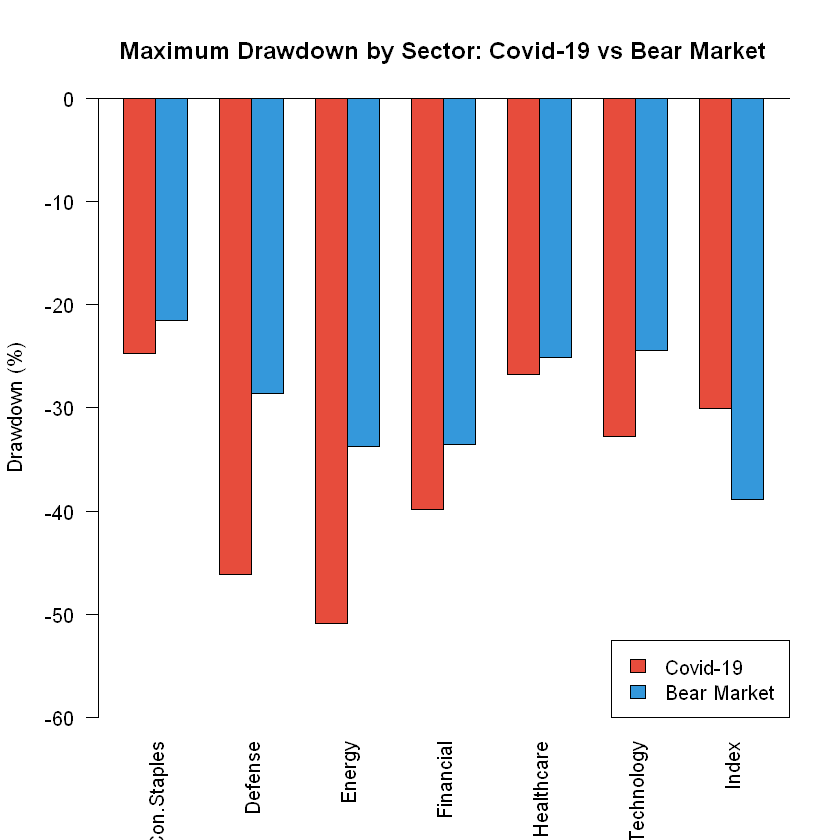

In [141]:
sectors <- c("Consumer_Staples", "Defense", "Energy", 
             "Financial", "Healthcare", "Technology", "Index")

drawdown_covid <- sector_summary[["drawdown_covid"]]
drawdown_bear  <- sector_summary[["drawdown_bear"]]

df_plot <- data.frame(
  sector = rep(sectors, 2),
  crash  = rep(c("Covid-19", "Bear Market"), each = 7),
  value  = c(drawdown_covid, drawdown_bear)
)

barplot(
  matrix(c(drawdown_covid, drawdown_bear), nrow = 2, byrow = TRUE),
  beside      = TRUE,
  names.arg   = c("Con.Staples", "Defense", "Energy", 
                  "Financial", "Healthcare", "Technology", "Index"),
  col         = c("#E74C3C", "#3498DB"),
  legend.text = c("Covid-19", "Bear Market"),
  args.legend = list(x = "bottomright"),
  main        = "Maximum Drawdown by Sector: Covid-19 vs Bear Market",
  ylab        = "Drawdown (%)",
  ylim        = c(-60, 0),
  las         = 2
)
abline(h = 0, col = "black", lwd = 1)

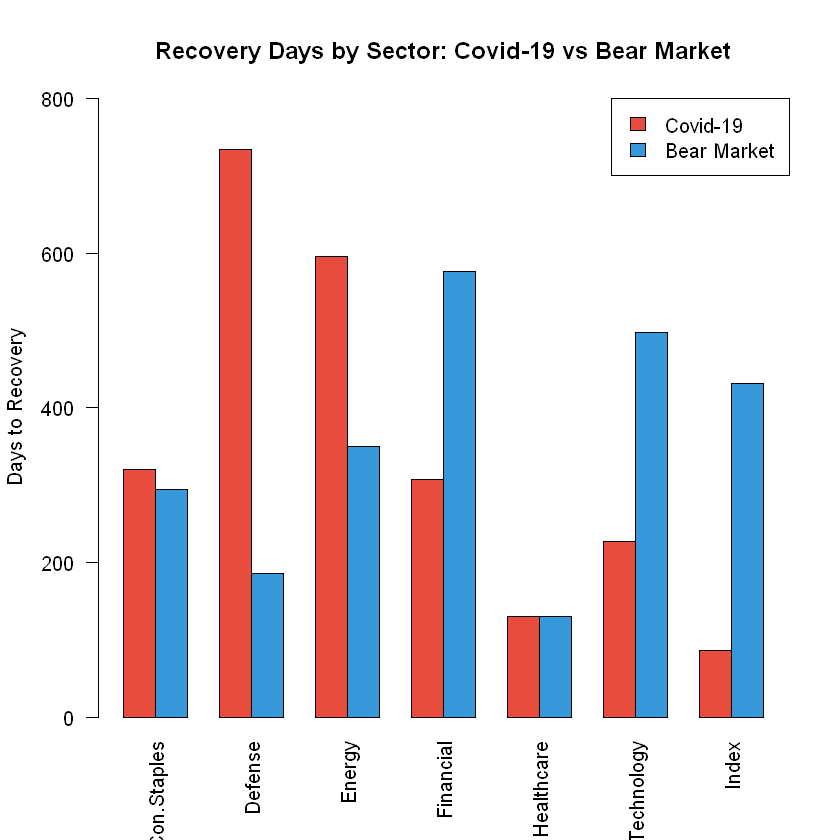

In [142]:
recovery_covid <- sector_summary[["recovery_covid_days"]]
recovery_bear  <- sector_summary[["recovery_bear_days"]]

barplot(
  matrix(c(recovery_covid, recovery_bear), nrow = 2, byrow = TRUE),
  beside      = TRUE,
  names.arg   = c("Con.Staples", "Defense", "Energy",
                  "Financial", "Healthcare", "Technology", "Index"),
  col         = c("#E74C3C", "#3498DB"),
  legend.text = c("Covid-19", "Bear Market"),
  args.legend = list(x = "topright"),
  main        = "Recovery Days by Sector: Covid-19 vs Bear Market",
  ylab        = "Days to Recovery",
  ylim        = c(0, 800),
  las         = 2
)

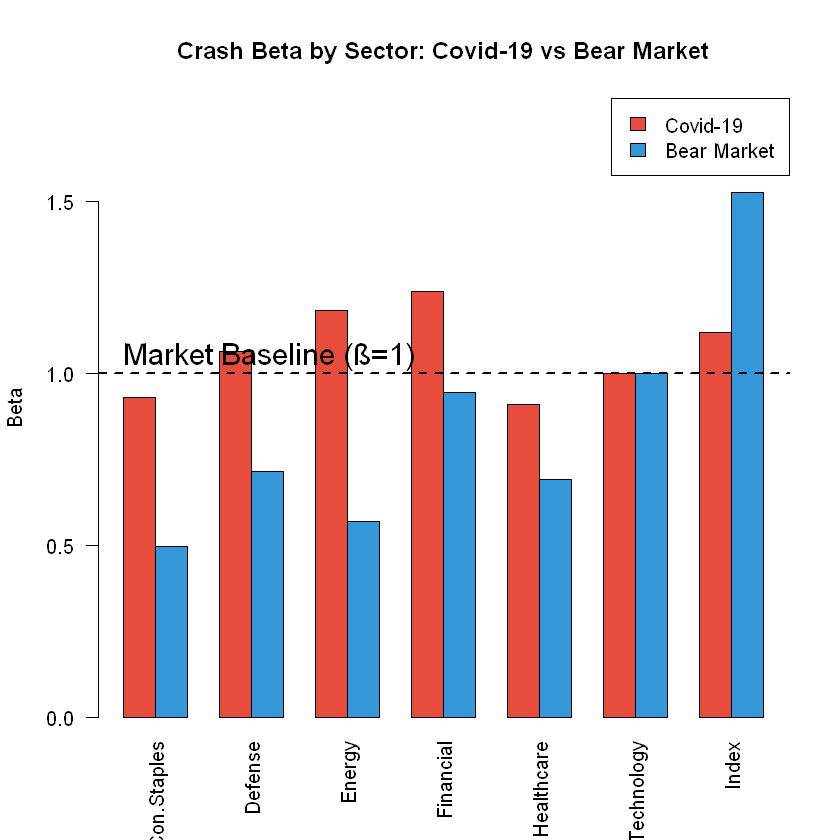

In [143]:
beta_covid <- sector_summary[["beta_covid"]]
beta_bear  <- sector_summary[["beta_bear"]]

bp <- barplot(
  matrix(c(beta_covid, beta_bear), nrow = 2, byrow = TRUE),
  beside      = TRUE,
  names.arg   = c("Con.Staples", "Defense", "Energy",
                  "Financial", "Healthcare", "Technology", "Index"),
  col         = c("#E74C3C", "#3498DB"),
  legend.text = c("Covid-19", "Bear Market"),
  args.legend = list(x = "topright"),
  main        = "Crash Beta by Sector: Covid-19 vs Bear Market",
  ylab        = "Beta",
  ylim        = c(0, 1.8),
  las         = 2
)
abline(h = 1.0, col = "black", lwd = 2, lty = 2)
text(x = 1, y = 1.05, labels = "Market Baseline (β=1)", adj = 0, cex = 1.5)

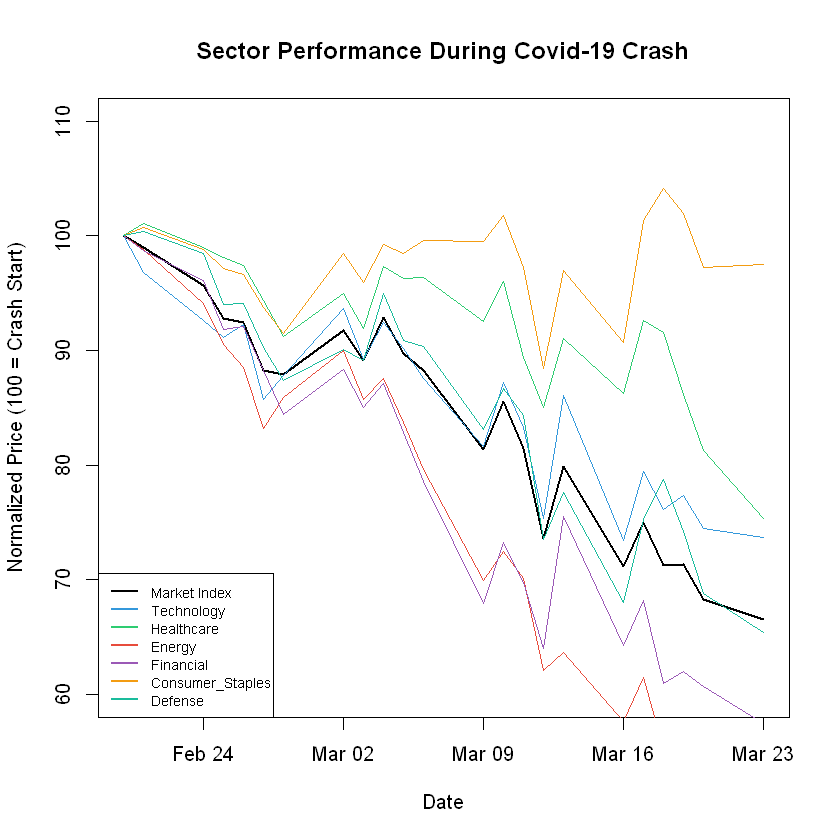

In [144]:
# Covid crash normalized price chart
covid_norm <- covid_df
first_row  <- as.numeric(covid_norm[1, ])
covid_norm <- sweep(covid_norm, 2, first_row, "/") * 100

# Define sector colors
sector_colors <- c(
  Technology       = "#3498DB",
  Healthcare       = "#2ECC71", 
  Energy           = "#E74C3C",
  Financial        = "#9B59B6",
  Consumer_Staples = "#F39C12",
  Defense          = "#1ABC9C",
  Market_Index     = "#000000"
)

# Get one representative stock per sector for cleaner chart
# or plot sector averages
plot(as.Date(rownames(covid_norm)), covid_norm[["SPY"]],
     type = "l", col = "black", lwd = 2,
     ylim = c(60, 110),
     xlab = "Date", ylab = "Normalized Price (100 = Crash Start)",
     main = "Sector Performance During Covid-19 Crash")

sector_stocks <- list(
  Technology = "MSFT", Healthcare = "JNJ", Energy = "XOM",
  Financial = "JPM", Consumer_Staples = "WMT", Defense = "LMT"
)

colors <- c("#3498DB", "#2ECC71", "#E74C3C", "#9B59B6", "#F39C12", "#1ABC9C")

for (i in seq_along(sector_stocks)) {
  stock <- sector_stocks[[i]]
  lines(as.Date(rownames(covid_norm)), covid_norm[[stock]],
        col = colors[i], lwd = 1.5)
}

legend("bottomleft",
       legend = c("Market Index", names(sector_stocks)),
       col    = c("black", colors),
       lwd    = 2, cex = 0.7)

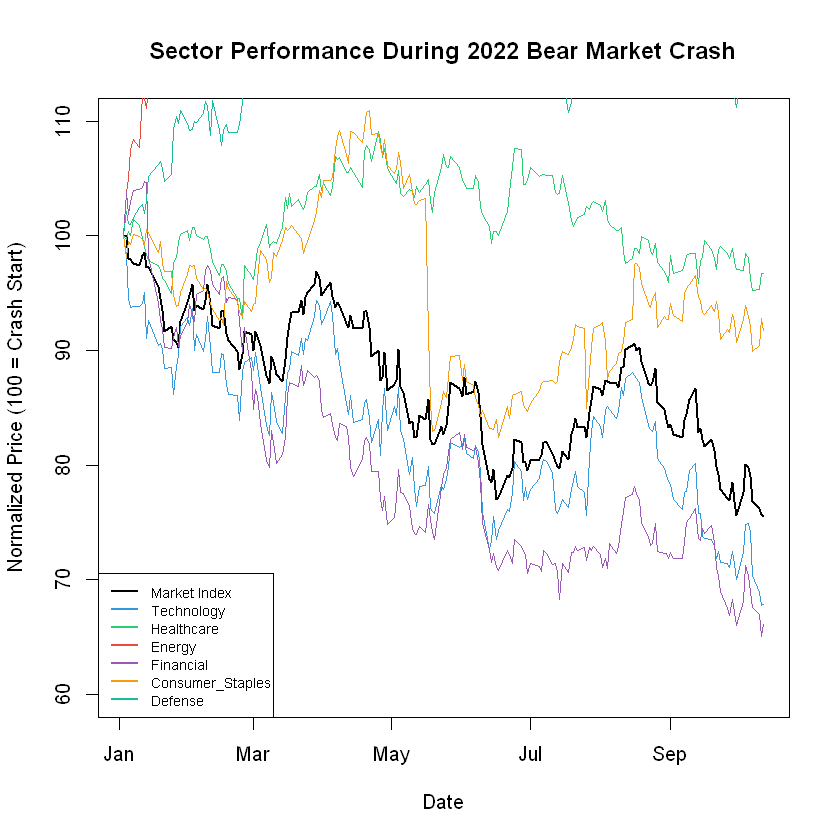

In [147]:
# Covid crash normalized price chart
bear_norm <- bear_df
first_row  <- as.numeric(bear_norm[1, ])
bear_norm <- sweep(bear_norm, 2, first_row, "/") * 100

# Define sector colors
sector_colors <- c(
  Technology       = "#3498DB",
  Healthcare       = "#2ECC71", 
  Energy           = "#E74C3C",
  Financial        = "#9B59B6",
  Consumer_Staples = "#F39C12",
  Defense          = "#1ABC9C",
  Market_Index     = "#000000"
)

# Get one representative stock per sector for cleaner chart
# or plot sector averages
plot(as.Date(rownames(bear_norm)), bear_norm[["SPY"]],
     type = "l", col = "black", lwd = 2,
     ylim = c(60, 110),
     xlab = "Date", ylab = "Normalized Price (100 = Crash Start)",
     main = "Sector Performance During 2022 Bear Market Crash")

sector_stocks <- list(
  Technology = "MSFT", Healthcare = "JNJ", Energy = "XOM",
  Financial = "JPM", Consumer_Staples = "WMT", Defense = "LMT"
)

colors <- c("#3498DB", "#2ECC71", "#E74C3C", "#9B59B6", "#F39C12", "#1ABC9C")

for (i in seq_along(sector_stocks)) {
  stock <- sector_stocks[[i]]
  lines(as.Date(rownames(bear_norm)), bear_norm[[stock]],
        col = colors[i], lwd = 1.5)
}

legend("bottomleft",
       legend = c("Market Index", names(sector_stocks)),
       col    = c("black", colors),
       lwd    = 2, cex = 0.7)

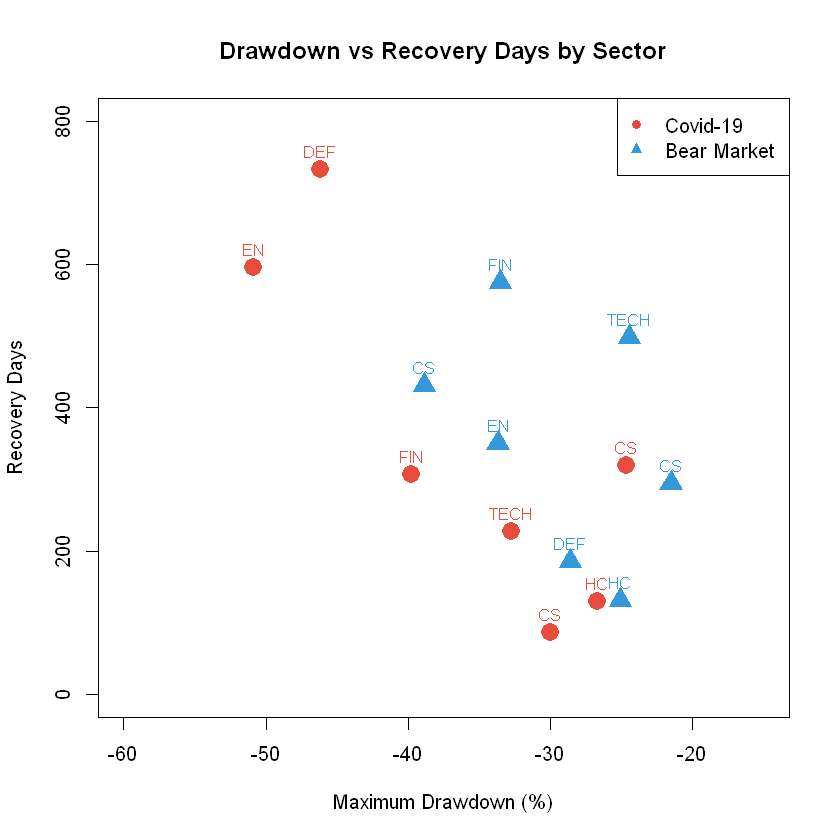

In [145]:
plot(drawdown_covid, recovery_covid,
     pch  = 16, col = "#E74C3C", cex = 2,
     xlim = c(-60, -15), ylim = c(0, 800),
     xlab = "Maximum Drawdown (%)",
     ylab = "Recovery Days",
     main = "Drawdown vs Recovery Days by Sector")

points(drawdown_bear, recovery_bear,
       pch = 17, col = "#3498DB", cex = 2)

# Label each point
text(drawdown_covid, recovery_covid,
     labels = c("CS", "DEF", "EN", "FIN", "HC", "TECH"),
     pos = 3, cex = 0.8, col = "#E74C3C")

text(drawdown_bear, recovery_bear,
     labels = c("CS", "DEF", "EN", "FIN", "HC", "TECH"),
     pos = 3, cex = 0.8, col = "#3498DB")

legend("topright",
       legend = c("Covid-19", "Bear Market"),
       pch    = c(16, 17),
       col    = c("#E74C3C", "#3498DB"))

We compared the behaviors of each stock sector across 2 distinct market crashes to understand how they behave in face of crisis. The 2 crashes differed in which the Covid-19 crash was due to severe demand/supply shock whereas the 2022 markey crash was due to monetary policy to combat inflation through raising interest rates.


Various metrics were utilized to help this analysis:

***Crash Beta:*** Measures how each sector moved in comparison with the market index (S&P500) during only each crash. Anything above 1 means more severe market loss where as below 1 means less severe. The above table calculates crash beta by averaging the crash beta for all stocks, and then grouping those averages by their sector. 

***Maximum Drawdown:*** Measures the capital loss from its pre-crash peak to trough, emphasizing on the real damage. The above table calculates this by averaging the maximum drawdown for all stocks, and then grouping those averages by their sector.

***Recovery Days:*** Measures how long each stock took to recover. The above table calculates this by averaging the recovery days for all stocks, and then grouping those averages by their sector.

****Commentary By Sector:****
1. Healthcare Sector: This sector stood out in both markey crashes. Both betas were considerably low (0.91 for covid, 0.69 for Bear), and saw the smallest drawdown aside from Consumer Staples Sector, and was even very fast at recovering from both crashes. The sector had identical recovery time at roughly 130 days for both market crashes, demonstrating how well the sector performs in crisis.
   
2. Consumer Staples Sector: This sector had one of the lowest betas across both markey crashes. However, what stood out most was the extremely slow recovery time for both markey crashes (320 days with Covid Crash and 295 days with Bear Market). This reveals that consumer staples preserves capital extremely well, but performs poorly with recoveries mainly due to its nature: sector companies are slow-growing.

3. Technology Sector: During the covid crash, the tech sector had a 1.12 beta and drawdown of -31.5%, but recovered the quickest of all at just 87 days. This was due to the demand/supply shock and the announcement of the lockdown actually boosted the recovery of tech sector. However during the bear market, tech had the highest beta at 1.53, and the worst drawdown at -39.2%, and took a long 432 days to recover. High interest rates reduce the present value of future earnings in this sector, and since tech stocks are valued on expectations of future growth, reducing those future earnings at higher rate are worth less today.

4. Energy Sector: Durinv Covid, the energy sector suffered the worst drawdown at -52.5% and took almost 600 days to recover, which was double the markey average. This was mainly due to the collapse in oil and energy demand as everyone was forced to stay home due to lockdown. On the otherhand, inflaton raised prices of commodities during the bear market, and energy had the second smallest drawdown at -34.3% and recovered in 350 days. This was the most severe reversal of behavior between the 2 crashes seen by any sector.

5. Financial Sector: During both crashes, the financial sector produced similar drawdowns (-40% for Covid, -33.6% for Bear), but there was a significant difference in recovery with covid taking only 307 days and bear taking 576 days. This actually makes sense as the covid panic was resolved quickly and stock liquidity was restored whereas the bear markey was caused by sustained high interest rates, creating structural pressure in lending margins and asset valuations that severely delayed recovery. 

6. Defense Sector: During Covid the beta was above market (1.07) and had a severe drawdown (-46.4%) with the slowest Covid recovery of any sector at 733 days. It is this slow since defence contractors rely on government contracts and government spending was frozen during Covid, which heavily relayed recovery. However during the bear market it transformed completely with beta dropping to 0.72, drawdown shrinking to just -28.6%, and it recovered in only 186 days, the fastest of any sector including Healthcare. This suggests Defense is not a traditional defensive sector in panic-driven crashes but becomes one of the strongest performers during geopolitically and inflation-driven environments, likely due to increased government defense spending during periods of global tension.

Across all 6 sectors, no single sector demonstrated superior performance across market crash types, which reinfornces the concept that the crash catalyst is what determines sector behavior.

### Phase 7: Evaluating Hypothesis ###

***Hypothesis:*** While defensive sectors (Healthcare and Consumer Staples) offer superior protection across market downturns, in other sectors, this is not the case as their protection depnd on the catalyst for the crash. Specifically, it is hypothesized that the Energy sector will be the worst performing sector during demand driven crashes (covid), but perform the best during inflation driven crashes (bear).

***Claim 1: Defensive Sectors (Consumer Staples and Healthcare) offer better protection during crashes.*** 

***Explanation:*** Healthcare fully explains this claim as it posted the lowest beta in both crashes, almost the smallest drawdowns, and the fastest recovery times of any sector in both crashes. No other sector reached this level, and offers extreme protection. Consumer staples confirms the claim on both beta and drawdown as well, and even had the smallest drawdowns of any sector in both crashes (-24.7 Covid, -21.6% Bear). However, the recovery for consumer staples was one of the slowest and this explains that preserving capital vs. recoery speed are 2 completley different things: a sector can protect you from going down, but will be against you on the way up, almost like a double-edged sword. Therefore, it is partially confirmed that defensive sectors contain drawdown losses effectively, but only healthcare consistently delivered superior protection across beta, drawdown, and recovery.

***Claim 2: Energy ranks the worst among all sectors in demand crashes, but outperforms inflation shocks (Bear Market Crash).***

***Explanation:*** During the covid demand crisis, energy had the worst drawdown of any sector at -52.5% and took 596 days to recover, which was double the market average at 227 days. During the 2022 crash however, the energy sector had the second smallest drawdown among all sectors at just -34.3% and recovered in just 350 days, outperforming technology adn financial sector as well as the market index in both metrics. No other sector demonstrated this kind of 180 in behavior between both crashes, making energy the most compelling proof that crash catalyst determines the performance of each sector in times of crisis.

***Unexpected Finding 1:*** The defense sector, not part of the original hypothesis, provided the second most compelling example that performance was based on crash catalyst. During covid, defense had an above market beta of 1.07, severe drawdown of -46.4%, and the slowest recovery of any sector at 733 days. Durign the bear market, it made a complete reversal, with beta dropping to 0.72, drawdown shrinking to -28.6%, and recovered the quickest at 186 days. This mirrors the behavior of the energy sector and furthe reinforces the hypothesis.

***Unexpected Finding 2:*** The technology sector revealed a pattern. It recovered the quickest of all sectors durign the Covid crash at just 87 days, despite a moderate beta and drawdown, but suffered the most during the bear market with the highest beta at 1.53, largest drawdown at -39.2%, and a 431 day recovery. This explains that technology sector stocks are especially vulnerable to interest rate factors. During panic crashes as seen with Covid, technology recovered quickly due to the rapid adoption of technology use, but with monetary policies like raising interest rates, it attacks the technology sector at its core, dealing the most severe damage.

***Overall Conclusion:*** The data broadly supports the hypothesis with one important refinement. While defensive sectors do offer meaningful downside protection, the degree of that protection varies — Healthcare is the only sector that delivers it consistently across all metrics and crash types, while Consumer Staples preserves capital on the way down but lags significantly on the way back up. The hypothesis claim regarding Energy is fully and decisively confirmed, with Energy demonstrating the most dramatic performance reversal of any sector between the two crashes. Beyond the original hypothesis, the Defense and Technology sectors emerge as the most interesting findings — both exhibiting extreme crash-type dependency in opposite directions. Taken together, these results strongly support the central argument that sector defensiveness is not a fixed property. The macroeconomic catalyst of a crash is the primary determinant of which sectors protect capital and which amplify losses, and any investment strategy that treats sector risk as static is likely to be caught off guard precisely when protection matters most.

### Conclusion ###

This analysis set out to answer whether certain sectors reliably protect investor capital during market downturns, and whether that protection holds across different types of crashes. The results tell a nuanced and compelling story.

Healthcare emerged as the only truly all-weather defensive sector in the dataset. Across both crashes it posted below-market beta, near-minimum drawdowns, and the fastest recovery times of any sector at approximately 130 days in both environments. It is the one sector an investor can hold with confidence regardless of what type of crisis unfolds.
Consumer Staples confirmed strong capital preservation on beta and drawdown — posting the smallest drawdowns of any sector in both crashes — but revealed a meaningful weakness in recovery speed, consistently lagging the market on the way back up. It protects capital going down but does not participate in rebounds, making it a double-edged holding.

The most important finding of the analysis is the confirmation that crash catalyst fundamentally determines cyclical sector performance. Energy was the worst performing sector during the Covid demand shock and the most improved during the inflationary bear market. No single sector demonstrated this reversal more dramatically, and it stands as decisive proof of the central thesis.
Beyond the original hypothesis, the Defense and Technology sectors provided unexpected but valuable additional evidence. Defense mirrored Energy's crash-type dependency in reverse — catastrophically slow to recover from panic-driven crashes but the fastest recovering sector of all during the inflationary environment. Technology showed the opposite asymmetry — snapping back fastest from Covid but suffering the deepest and most prolonged damage during monetary tightening.

Taken together, these findings challenge the conventional wisdom of treating sectors as having fixed defensive or aggressive properties. Sector behavior is dynamic, not static. The macroeconomic catalyst of a crash — whether demand shock, liquidity panic, or monetary tightening — is the primary determinant of which sectors protect capital and which amplify losses. An investor who understands this distinction is fundamentally better equipped to position their portfolio before a crisis than one who relies on sector labels alone.